In [1]:
##CNN Image Classification

C:\Users\mdeer\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.4459 - loss: 1.5164 - val_accuracy: 0.5607 - val_loss: 1.2250
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.5919 - loss: 1.1528 - val_accuracy: 0.6358 - val_loss: 1.0473
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.6458 - loss: 1.0056 - val_accuracy: 0.6519 - val_loss: 1.0114
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.6812 - loss: 0.9115 - val_accuracy: 0.6725 - val_loss: 0.9497
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7081 - loss: 0.8324 - val_accuracy: 0.6788 - val_loss: 0.9267
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6788 - loss: 0.9267
Test Accuracy: 0.6787999868392944


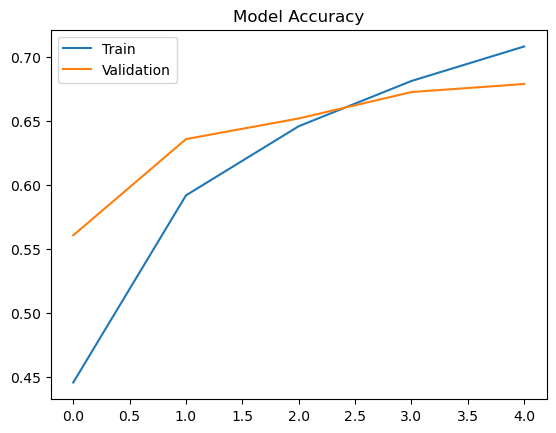

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Load Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN Model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10)
])

# Compile
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train
history = model.fit(X_train,y_train,epochs=5,
                    validation_data=(X_test,y_test))

# Evaluate
test_loss,test_acc = model.evaluate(X_test,y_test)

print("Test Accuracy:",test_acc)

# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()